# Person Search on PRW
## Machine Learning for Computer Vision — University of Bologna, A.Y. 2025–2026

| | |
|---|---|
| **Student ID** | 0001191564 |
| **Name** | Alessandro Capialbi |
| **Email** | alessandro.capialbi@studio.unibo.it |


## Setup

The cells below require only `matplotlib`, `Pillow`, `numpy`, and `pandas` (no GPU, no PyTorch). 


In [21]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

ROOT = Path(".")

# Pre-computed outputs live here; produced by visualize.py (see README)
VIS_DIR  = ROOT / "vis" / "baseline"
CKPT_DIR = ROOT / "checkpoints"


## 1. Task Overview

**Person Search** is the task of jointly solving pedestrian *detection* and person *re-identification* in a single, end-to-end trainable model. Unlike standard Re-ID (which assumes perfect pre-cropped inputs), Person Search ingests full scene images and must simultaneously locate all persons and identify the target — a more realistic and challenging problem for surveillance applications.

Given a **query** (a bounding-box crop of a person), the model ranks all persons detected in a **gallery** of raw scene images by their similarity to the query. Performance is measured by **mAP** and **top-1 accuracy** under the official PRW protocol (IoU > 0.5 for a detection to count as correct).

Our approach is a unified **Faster R-CNN** model with a parallel re-ID head trained jointly with the detector via the **Online Instance Matching (OIM)** loss.


## 2. Model Architecture

The baseline is a **joint detection + re-identification** model built on torchvision's Faster R-CNN:

| Component | Choice | Details |
|---|---|---|
| Backbone | ResNet-101 + FPN | ImageNet weights; conv1 + layer1 frozen; all BN frozen |
| RPN anchors | aspect ratios (1:1, 1:2, 1:3) | Tall/narrow bias for pedestrians |
| Detection head | 2-class (bg / person) | Fast R-CNN classifier + box regressor |
| Re-ID head | GAP → FC → BN → L2-norm | 256-d unit-sphere embedding per person |
| Re-ID loss | OIM (momentum LUT + circular queue) | 483 LUT slots + 500 unlabeled negatives, momentum 0.5 |
| NMS threshold | 0.4 | More aggressive than default 0.5; reduces duplicates in crowds |
| Inference ranking | CWS (Confidence-Weighted Similarity) | Gallery embedding × detection score |

**Training:** SGD lr=0.0015, linear warmup (1000 iter), MultiStepLR [epoch 10, 14] γ=0.1, 16 epochs, batch size 2, mixed precision (AMP). OIM memory updates are forced to fp32 via `custom_fwd(cast_inputs=fp32)` to avoid dtype mismatches under autocast.


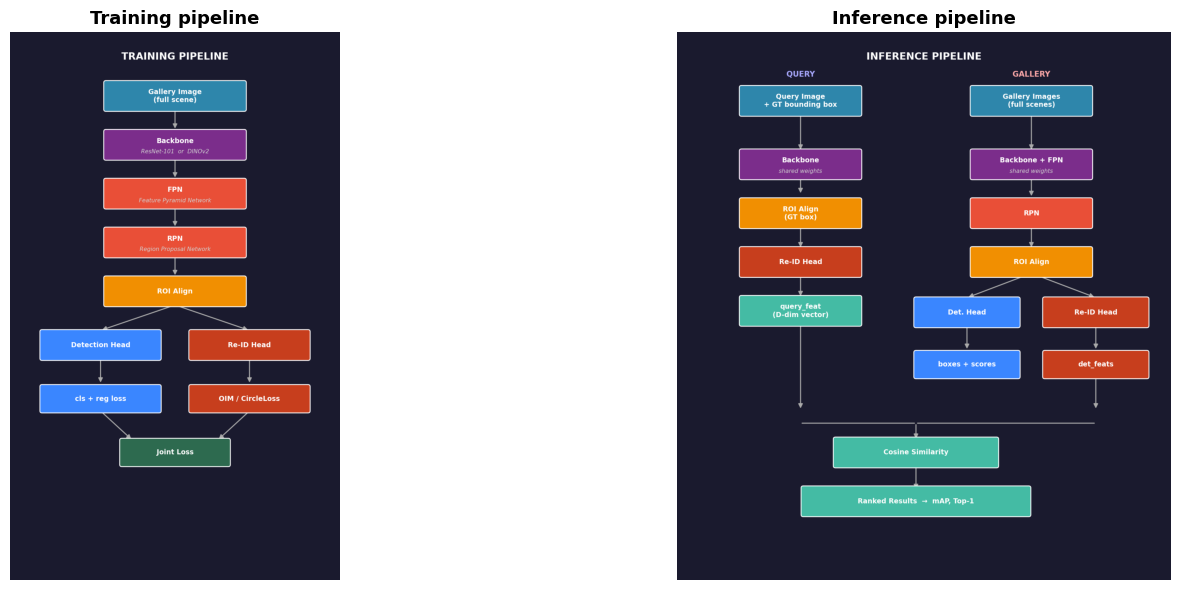

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, name, title in zip(
    axes,
    ["pipeline_training.png", "pipeline_inference.png"],
    ["Training pipeline", "Inference pipeline"],
):
    p = ROOT / "assets" / name
    if p.exists():
        ax.imshow(Image.open(p))
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.axis("off")
plt.tight_layout()
plt.show()


## 3. Dataset: PRW

**Person Re-identification in the Wild** (PRW) [Zheng et al., CVPR 2017] is recorded by 6 fixed cameras on a university campus and is the standard benchmark for the Person Search task.

| Split | Frames | Identities | Pedestrians | With ID | Without ID |
|-------|--------|-----------|-------------|---------|------------|
| Train | 5,134  | 482       | 16,243      | 13,416  | 2,827      |
| Test  | 6,112  | 450       | 25,062      | 19,127  | 5,935      |
| **Total** | **11,816** | **932** | **43,110** | **34,034** | **9,076** |

Raw identity labels (non-contiguous in [1, 932]) are re-mapped to a dense range [0, 482] for the OIM look-up table. Persons marked *ambiguous* (pid = −2) are treated as unlabeled and fed into the OIM circular queue as extra negatives.

Dataset available on [Kaggle](https://www.kaggle.com/datasets/edoardomerli/prw-person-re-identification-in-the-wild).


## 4. Qualitative Results — Pedestrian Detection

Detection boxes (score ≥ 0.5) overlaid on 6 randomly sampled gallery scenes. Images produced by `visualize.py` and stored in `vis/baseline/detections/`.


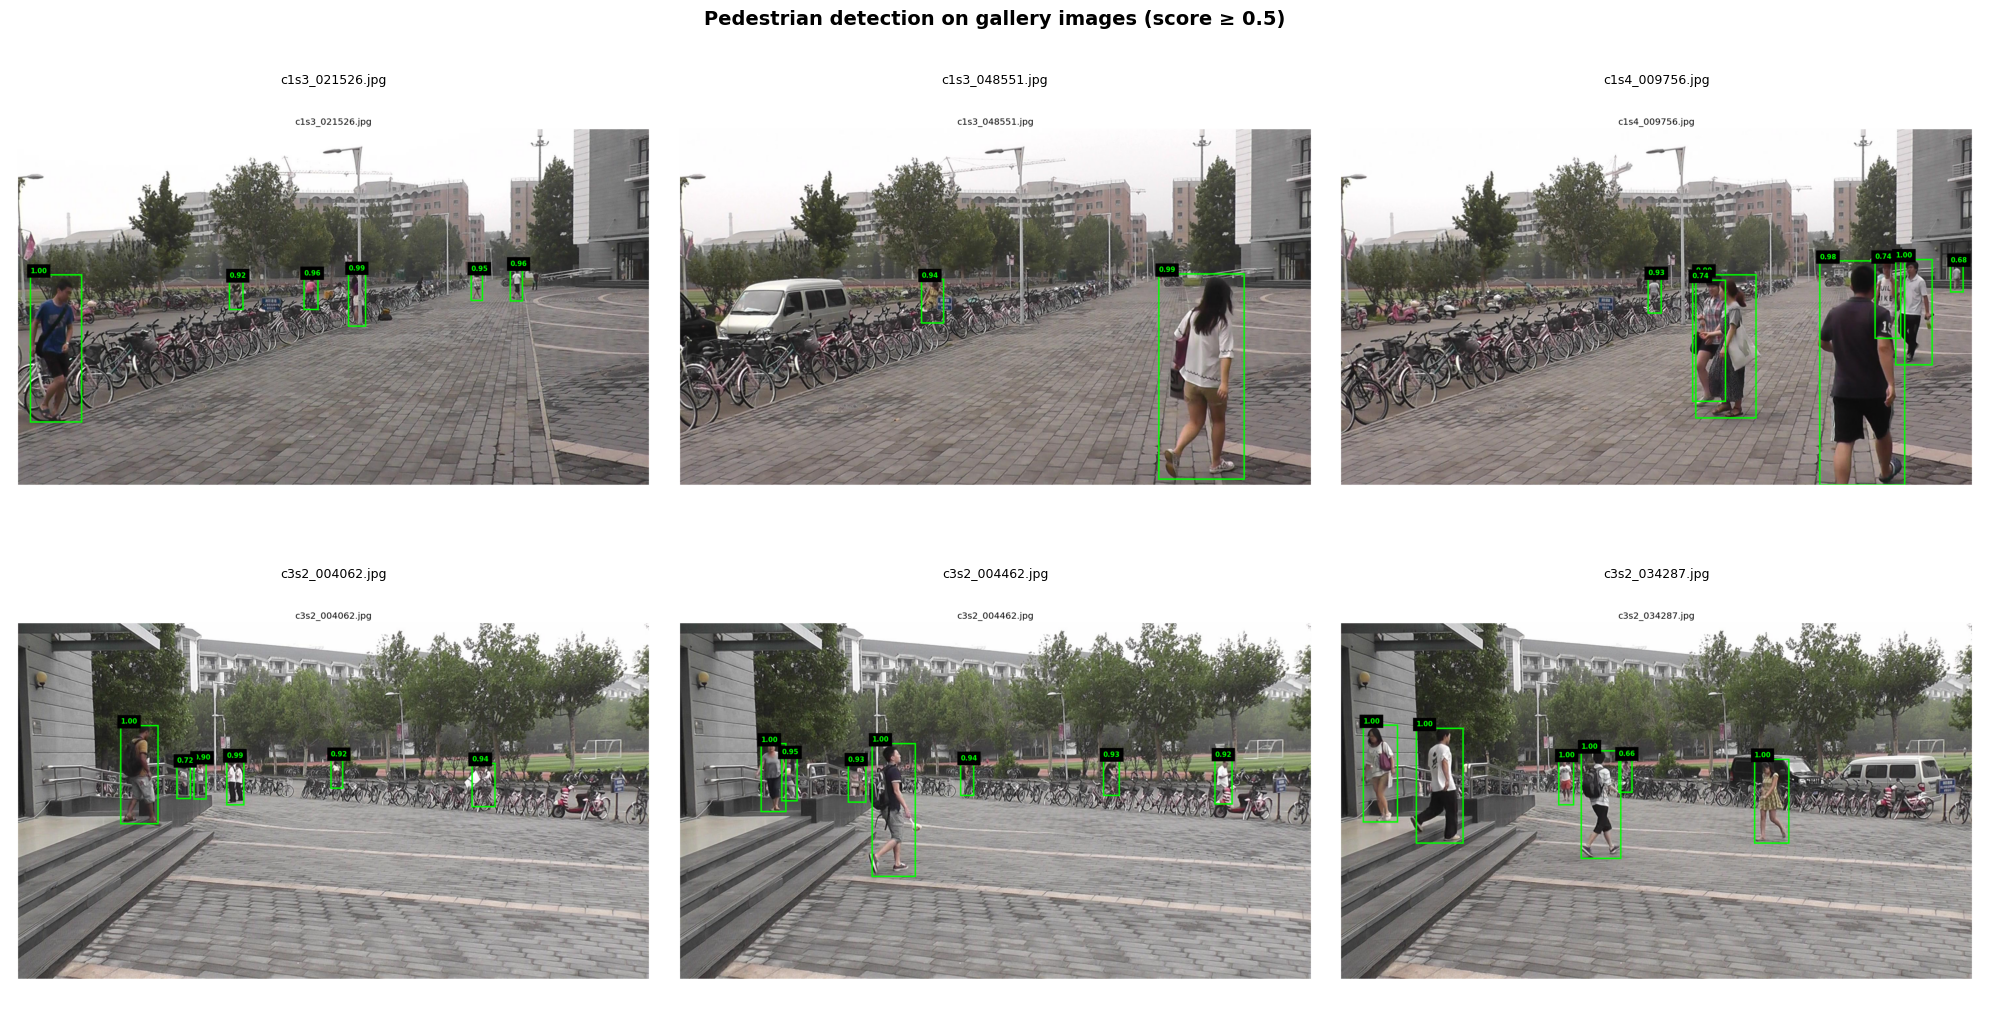

In [23]:
det_imgs = sorted((VIS_DIR / "detections").glob("*.png"))[:6]

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
for ax, p in zip(axes.flat, det_imgs):
    ax.imshow(Image.open(p))
    ax.set_title(p.stem.replace("det_", ""), fontsize=9)
    ax.axis("off")
plt.suptitle("Pedestrian detection on gallery images (score ≥ 0.5)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 5. Qualitative Results — Person Search Rankings

For each query the model detects all persons in the full gallery (6,112 images) and ranks them by Confidence-Weighted Similarity. **Left column**: query crop. **Green** border = correct match (same identity), **red** = wrong match. Images produced by `visualize.py` and stored in `vis/baseline/rankings/`.


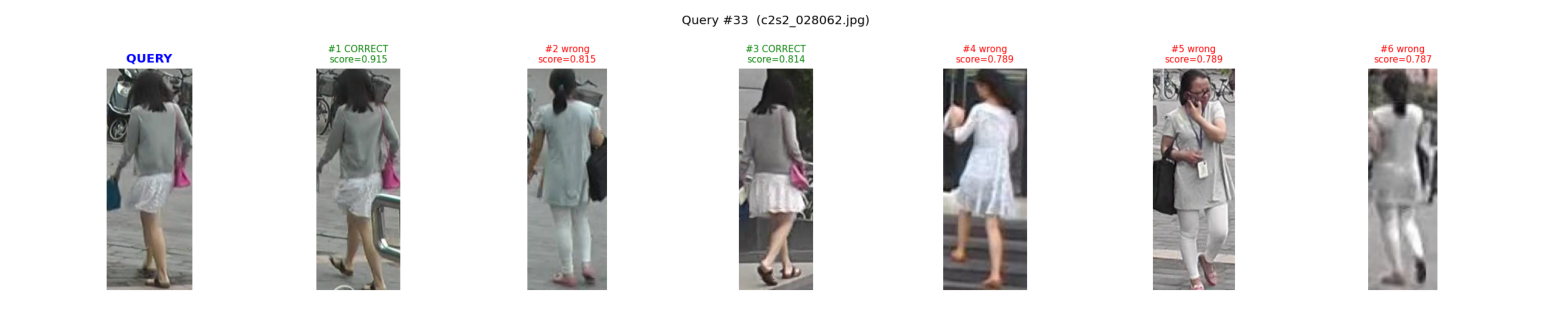

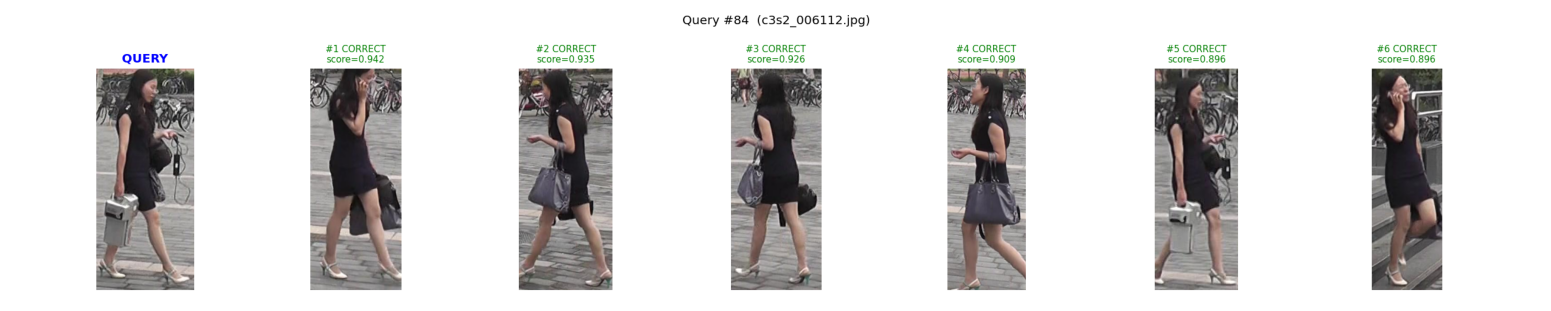

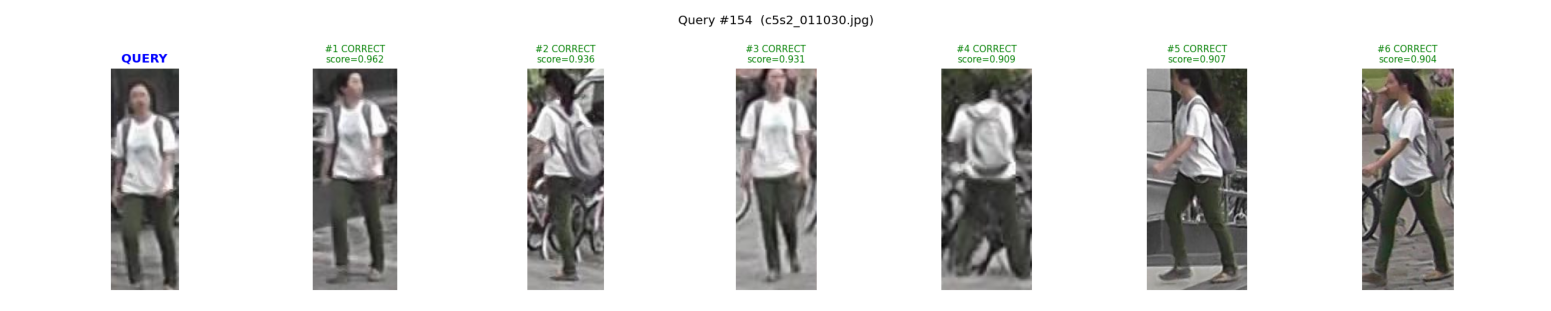

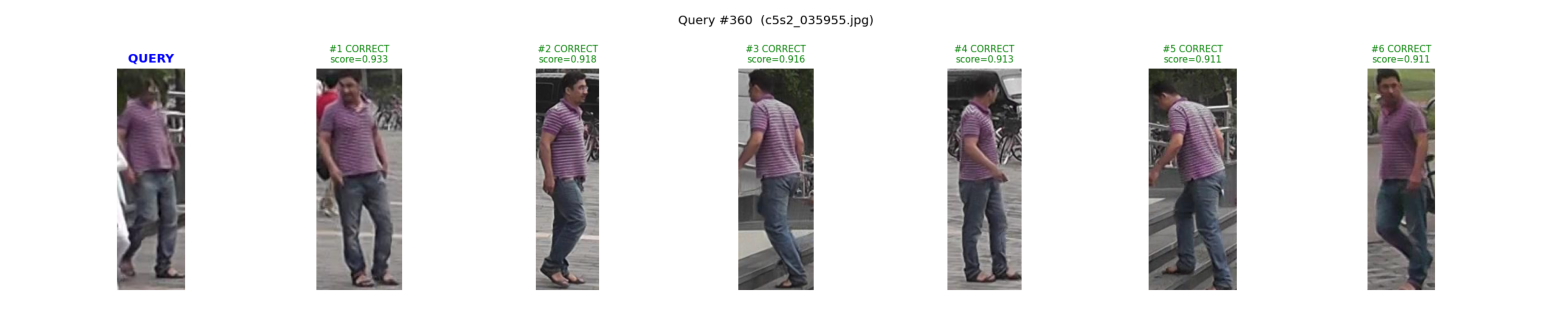

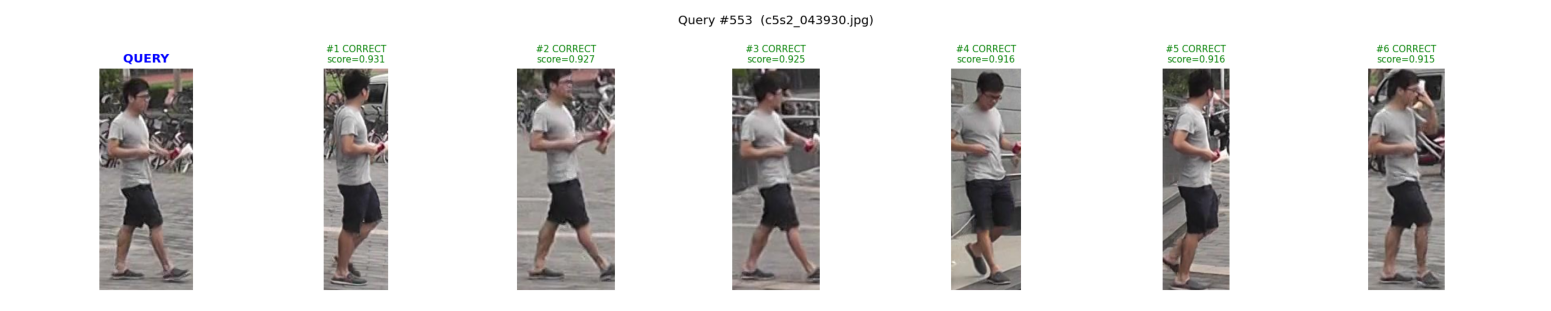

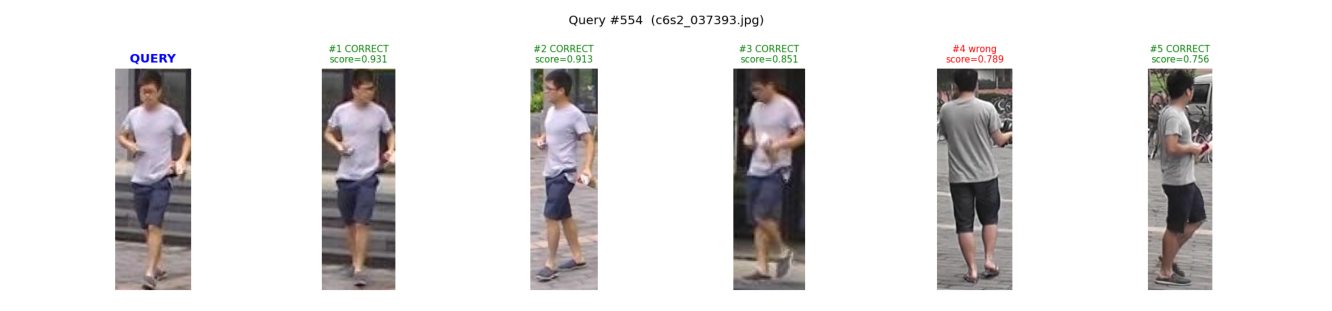

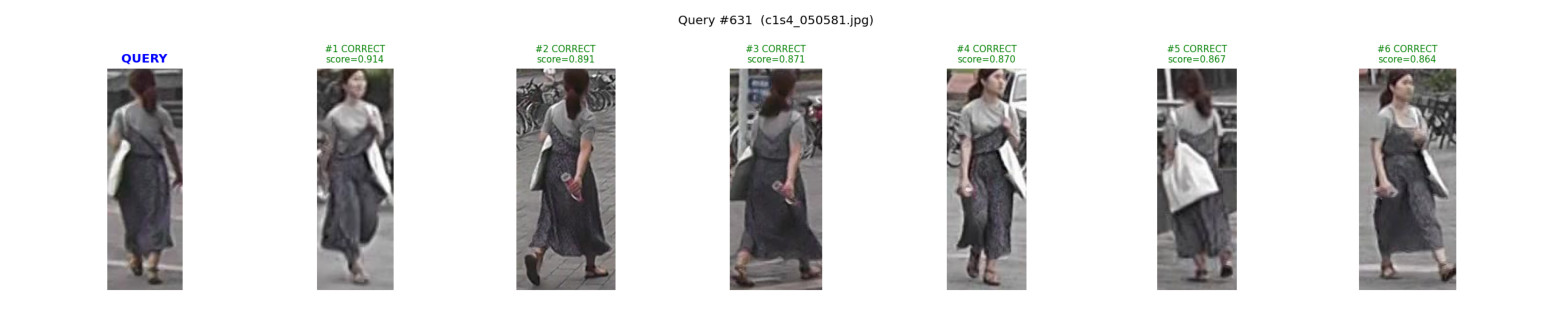

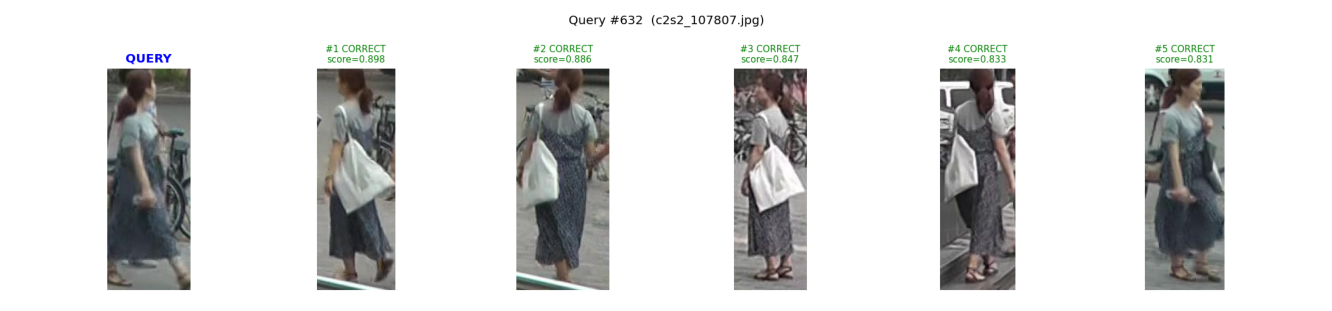

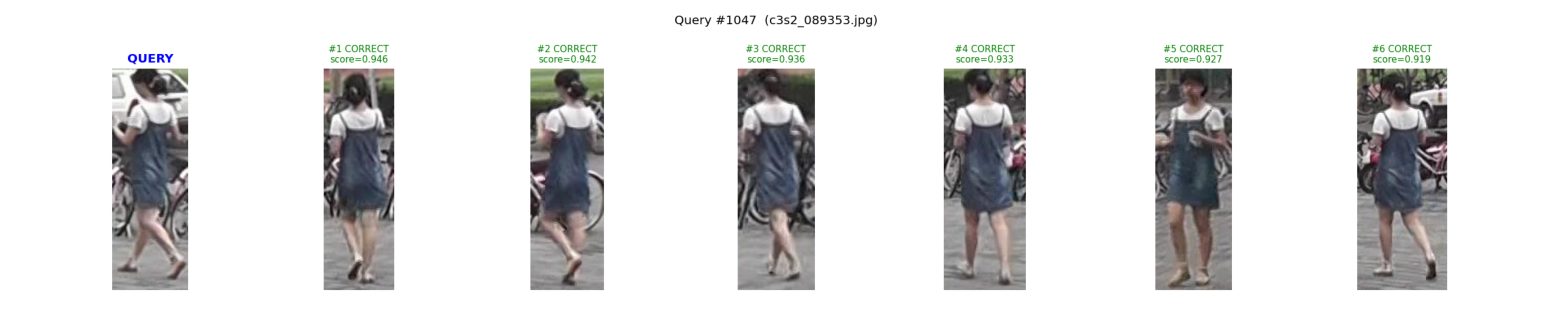

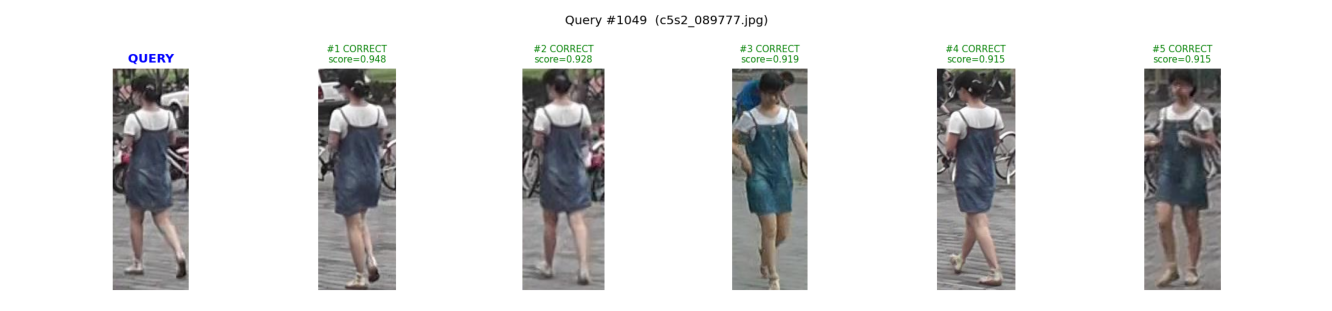

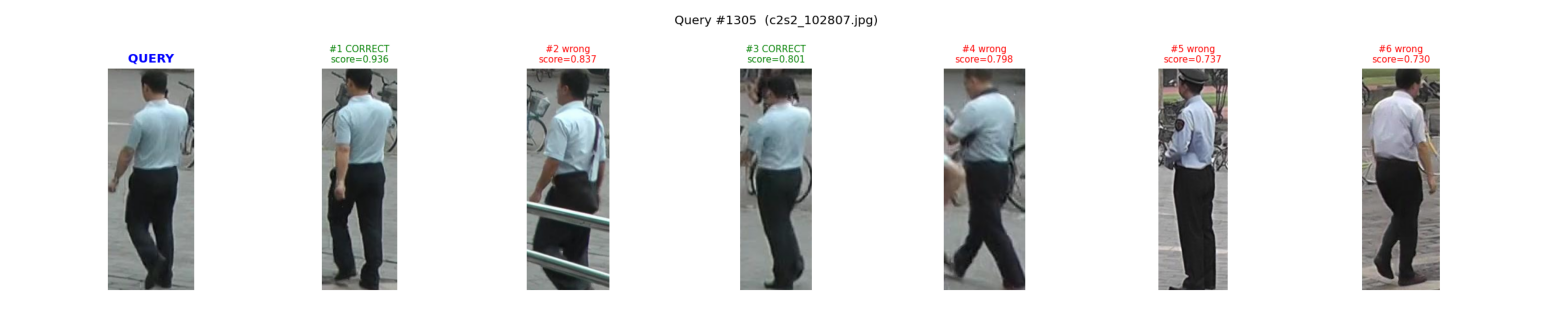

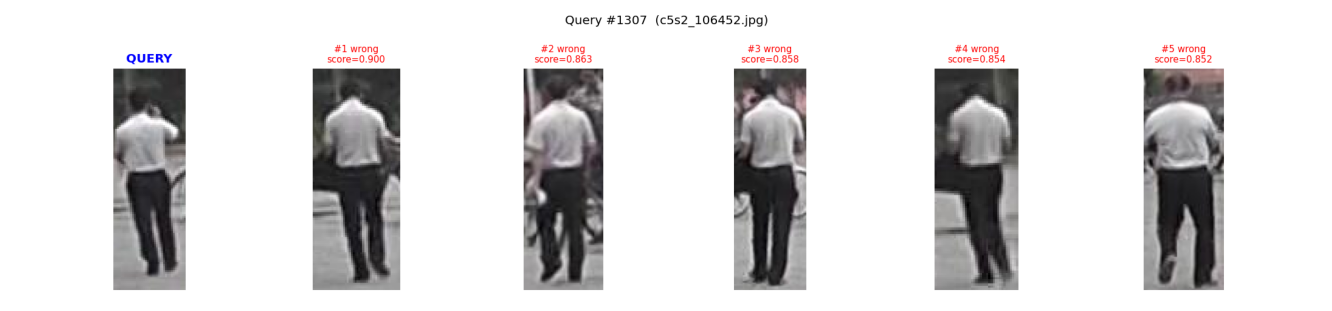

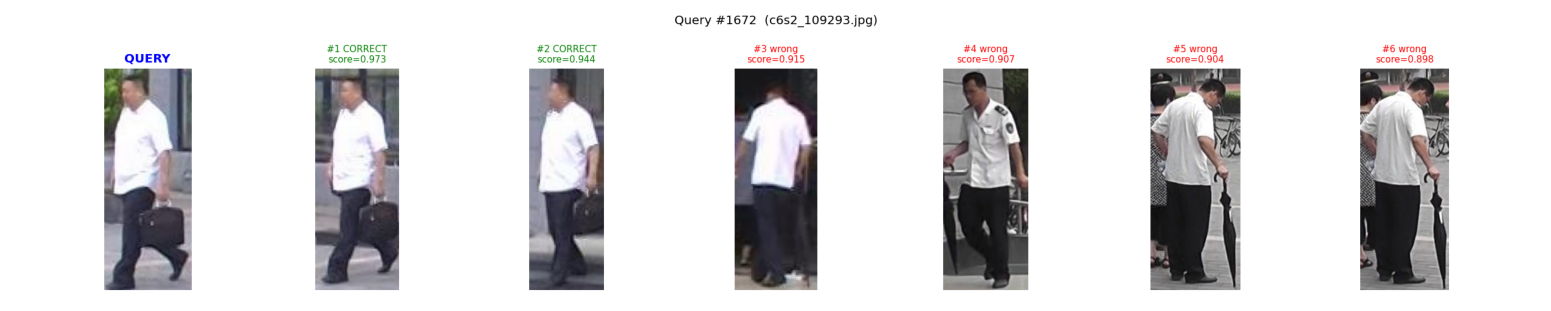

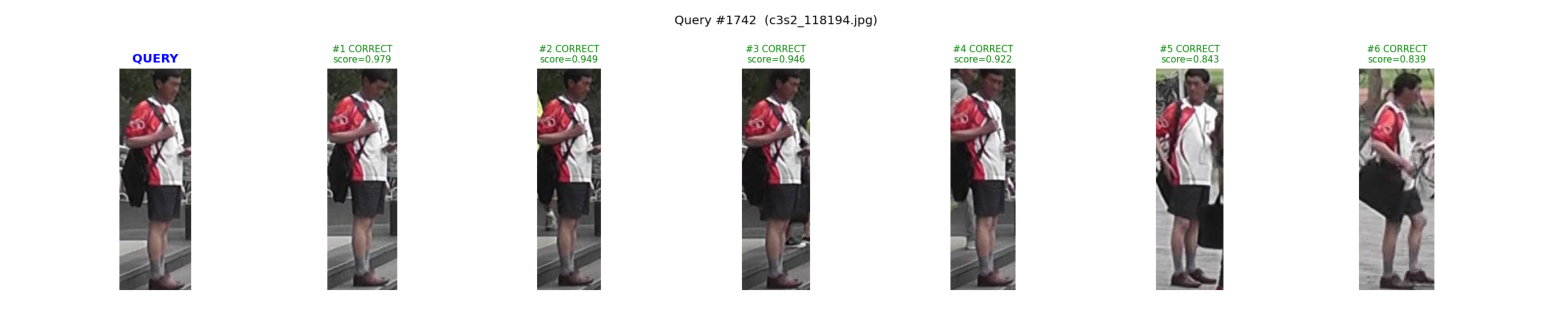

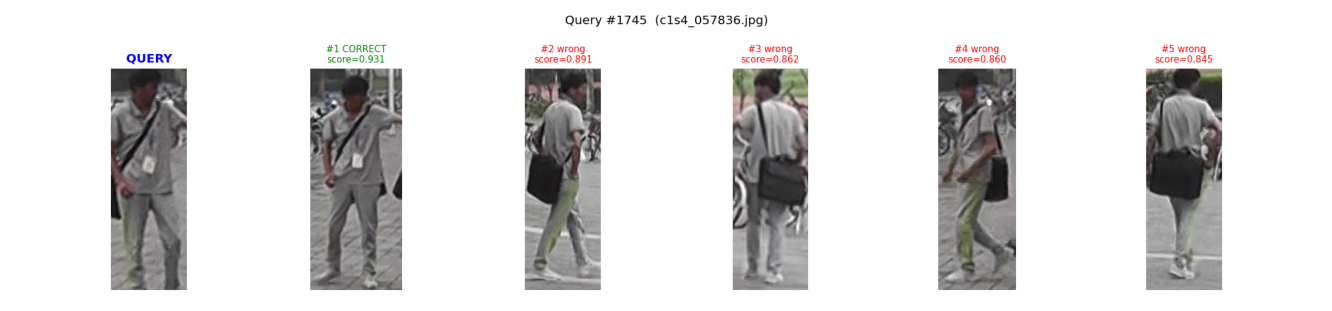

In [24]:
rank_imgs = sorted((VIS_DIR / "rankings").glob("*.png"))

for p in rank_imgs:
    fig, ax = plt.subplots(figsize=(20, 3))
    ax.imshow(Image.open(p))
    ax.axis("off")
    plt.tight_layout(pad=0.3)
    plt.show()


## 6. Quantitative Results — Baseline

Evaluation uses the official `eval_search_prw` protocol:
- A detection is a **true positive** if IoU > 0.5 with the GT box *and* the identity matches.
- `ignore_cam_id=True`: gallery images from the same camera as the query are excluded (standard in the literature).
- `det_thresh=0.5`; ranking uses CWS (gallery embedding × detection score).

Results are loaded from `checkpoints/baseline/metrics.json` (pre-computed; see the optional section at the end to reproduce from scratch).


In [25]:
with open(CKPT_DIR / "baseline" / "metrics.json") as f:
    baseline_metrics = json.load(f)

print("Baseline — ResNet-101 + FPN + OIM")
print(f"  mAP   = {baseline_metrics['mAP']:.2%}")
print(f"  top-1 = {baseline_metrics['top1']:.2%}")


Baseline — ResNet-101 + FPN + OIM
  mAP   = 41.72%
  top-1 = 79.78%


## 7. Ablation Study

Three variants of the baseline are trained changing **exactly one component** at a time. All other hyper-parameters are identical (seed 42, lr=0.0015, 16 epochs, batch 2, same PRW split).


### Ablation 1 — Backbone: DINOv2 ViT-B/14

ResNet-101 + FPN is replaced with **DINOv2 ViT-B/14** (86 M params, self-supervised pre-training on LVD-142M). A plain ViT produces a single feature resolution, so we add a **ViTDet-style Simple Feature Pyramid (SFP)** that derives four FPN-compatible levels from the patch-token grid (patch size 14) via bilinear upsampling (×4, ×2) and strided convolutions (×2, pool×4). The last 6 of 12 transformer blocks and LayerNorm are fine-tuned at lr × 0.1 relative to the detection head.

```bash
python train.py --backbone dinov2 --out-dir checkpoints/dinov2_fair --eval-at-end
```


In [26]:
with open(CKPT_DIR / "dinov2_fair" / "metrics.json") as f:
    dino_metrics = json.load(f)

print("Ablation 1 — DINOv2 ViT-B/14 + SFP + OIM")
print(f"  mAP   = {dino_metrics['mAP']:.2%}  "
      f"(baseline {baseline_metrics['mAP']:.2%},  "
      f"Δ = {dino_metrics['mAP'] - baseline_metrics['mAP']:+.2%})")
print(f"  top-1 = {dino_metrics['top1']:.2%}  "
      f"(baseline {baseline_metrics['top1']:.2%},  "
      f"Δ = {dino_metrics['top1'] - baseline_metrics['top1']:+.2%})")


Ablation 1 — DINOv2 ViT-B/14 + SFP + OIM
  mAP   = 20.70%  (baseline 41.72%,  Δ = -21.02%)
  top-1 = 57.07%  (baseline 79.78%,  Δ = -22.70%)


**Result: mAP = 20.70% — drop of −21 pp from the baseline.**

The gap is structurally motivated:

1. **Dataset scale mismatch.** DINOv2-B was designed for large-scale tasks; with only 5,704 training frames, partial fine-tuning cannot fully adapt its representations to the joint detection + re-ID task.
2. **Artificial feature pyramid.** ResNet-FPN produces true multi-scale features (strides 4/8/16/32/64) because each stage processes the image at a different resolution. The SFP derives all scales synthetically from a single stride-14 feature map, putting small-object RPN proposals at a structural disadvantage.
3. **Architecture mismatch.** Faster R-CNN was co-designed with CNN-FPN backbones. ViTDet-style detectors typically require window attention and propagation layers beyond the scope of this ablation.


### Ablation 2 — Loss Function: Circle Loss

OIM is replaced with **Circle Loss** (Sun et al., CVPR 2020). Circle Loss uses a learnable weight matrix of class centres (one 256-d vector per identity, unit-normalised) instead of OIM's non-parametric LUT + queue. Per-pair adaptive weights α_p and α_n focus training on pairs near the decision boundary (m=0.25, γ=256).

```bash
python train.py --reid-loss circle --out-dir checkpoints/circle --eval-at-end
```


In [27]:
with open(CKPT_DIR / "circle" / "metrics.json") as f:
    circle_metrics = json.load(f)

print("Ablation 2 — ResNet-101 + FPN + Circle Loss")
print(f"  mAP   = {circle_metrics['mAP']:.2%}  "
      f"(baseline {baseline_metrics['mAP']:.2%},  "
      f"Δ = {circle_metrics['mAP'] - baseline_metrics['mAP']:+.2%})")
print(f"  top-1 = {circle_metrics['top1']:.2%}  "
      f"(baseline {baseline_metrics['top1']:.2%},  "
      f"Δ = {circle_metrics['top1'] - baseline_metrics['top1']:+.2%})")


Ablation 2 — ResNet-101 + FPN + Circle Loss
  mAP   = 41.30%  (baseline 41.72%,  Δ = -0.42%)
  top-1 = 78.80%  (baseline 79.78%,  Δ = -0.97%)


**Result: mAP = 41.30% — essentially identical to the baseline (−0.42 pp).**

With only 482 training identities the two losses provide equivalent supervision: OIM's running-average LUT already delivers stable, dense negatives comparable to Circle Loss's explicit class centres. Circle Loss's advantages (adaptive margins, no queue-size hyper-parameter) become relevant only at larger scales (Market-1501, DukeMTMC) where per-identity LUT update frequency becomes sparse.


### Ablation 3 — Data Augmentation: Color Jitter

The baseline is augmented with **Color Jitter** during training: random brightness, contrast and saturation perturbations (each ±20%, applied independently with p=0.5 per channel).

PRW is recorded by 6 cameras with different sensor characteristics and illumination conditions, creating a systematic colour gap between query and gallery crops. Colour Jitter exposes the model to varied colour statistics at training time, improving embedding invariance to camera-specific shifts without altering the spatial structure of the image — unlike Random Erasing on full detection images, which degrades RPN quality.

```bash
python train.py --color-jitter --out-dir checkpoints/color_jitter --eval-at-end
```


In [28]:
with open(CKPT_DIR / "color_jitter" / "metrics.json") as f:
    cj_metrics = json.load(f)

print("Ablation 3 — ResNet-101 + FPN + OIM + Color Jitter")
print(f"  mAP   = {cj_metrics['mAP']:.2%}  "
      f"(baseline {baseline_metrics['mAP']:.2%},  "
      f"Δ = {cj_metrics['mAP'] - baseline_metrics['mAP']:+.2%})")
print(f"  top-1 = {cj_metrics['top1']:.2%}  "
      f"(baseline {baseline_metrics['top1']:.2%},  "
      f"Δ = {cj_metrics['top1'] - baseline_metrics['top1']:+.2%})")


Ablation 3 — ResNet-101 + FPN + OIM + Color Jitter
  mAP   = 41.86%  (baseline 41.72%,  Δ = +0.14%)
  top-1 = 78.71%  (baseline 79.78%,  Δ = -1.07%)


**Result: mAP = 41.86% — modest improvement of +0.14 pp.**

The gain is small but consistent: colour augmentation improves re-ID embedding robustness across cameras without affecting detection quality (identical `loss_objectness` and `loss_rpn_box_reg` trajectories). The small magnitude reflects PRW's compact size; larger gains would require more aggressive multi-camera domain adaptation.


### Summary


In [29]:
try:
    import pandas as pd
    rows = [
        ("Baseline",   "ResNet-101 + FPN", "OIM",         "—",
         f"{baseline_metrics['mAP']*100:.2f}", f"{baseline_metrics['top1']*100:.2f}"),
        ("Ablation 1", "DINOv2 ViT-B/14",  "OIM",         "—",
         f"{dino_metrics['mAP']*100:.2f}",     f"{dino_metrics['top1']*100:.2f}"),
        ("Ablation 2", "ResNet-101 + FPN", "Circle Loss", "—",
         f"{circle_metrics['mAP']*100:.2f}",   f"{circle_metrics['top1']*100:.2f}"),
        ("Ablation 3", "ResNet-101 + FPN", "OIM",         "Color Jitter",
         f"{cj_metrics['mAP']*100:.2f}",       f"{cj_metrics['top1']*100:.2f}"),
    ]
    df = pd.DataFrame(
        rows,
        columns=["Experiment", "Backbone", "Loss", "Augmentation", "mAP (%)", "top-1 (%)"]
    ).set_index("Experiment")
    display(df)
except ImportError:
    header = f"{'Experiment':<14} {'Backbone':<18} {'Loss':<12} {'Augmentation':<14} {'mAP':>7} {'top-1':>8}"
    print(header)
    print("-" * len(header))
    for name, bb, loss, aug, m, t in [
        ("Baseline",   "ResNet-101+FPN",  "OIM",         "—",            baseline_metrics['mAP'], baseline_metrics['top1']),
        ("Ablation 1", "DINOv2 ViT-B/14", "OIM",         "—",            dino_metrics['mAP'],     dino_metrics['top1']),
        ("Ablation 2", "ResNet-101+FPN",  "Circle Loss", "—",            circle_metrics['mAP'],   circle_metrics['top1']),
        ("Ablation 3", "ResNet-101+FPN",  "OIM",         "Color Jitter", cj_metrics['mAP'],       cj_metrics['top1']),
    ]:
        print(f"{name:<14} {bb:<18} {loss:<12} {aug:<14} {m*100:>6.2f}% {t*100:>7.2f}%")


,Backbone,Loss,Augmentation,mAP (%),top-1 (%)
Experiment,,,,,
Baseline,ResNet-101 + FPN,OIM,—,41.72,79.78
Ablation 1,DINOv2 ViT-B/14,OIM,—,20.70,57.07
Ablation 2,ResNet-101 + FPN,Circle Loss,—,41.30,78.80
Ablation 3,ResNet-101 + FPN,OIM,Color Jitter,41.86,78.71


## 8. Conclusions

All four experiments share identical hyper-parameters and evaluation protocol. Key findings:

- **Backbone dominates** (Ablation 1, −21 pp): ResNet-101 + FPN is far more suitable than DINOv2 ViT-B/14 for a two-stage detector trained on a small dataset. The CNN's native multi-scale features and architectural compatibility with Faster R-CNN are decisive.

- **Loss function is neutral at this scale** (Ablation 2, −0.42 pp): OIM and Circle Loss converge to the same point on PRW's 482 identities. Both supply sufficient negative supervision; Circle Loss's adaptive margins matter only at larger scales.

- **Appearance augmentation gives a reliable small gain** (Ablation 3, +0.14 pp): Color Jitter improves cross-camera embedding robustness without disrupting detection, confirming that *structure-preserving* augmentation is the right choice for the joint detection + re-ID task.

---

**Reference:** Xiao et al., *"Joint Detection and Identification Feature Learning for Person Search"*, CVPR 2017. OIM implementation adapted from SeqNet (https://github.com/serend1p1ty/SeqNet).
